In [19]:
Avg_acc_all_dataset=[]
Avg_acc_all_dataset_without_FS=[]
Avg_feature_all_dataset=[]
Avg_fitness_all_dataset=[]

In [20]:
import pandas as pd
import numpy as np
import random
import math

In [21]:
data=pd.read_csv('csv_result-CM1.csv')
data.head()

,id,LOC_BLANK,BRANCH_COUNT,CALL_PAIRS,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CONDITION_COUNT,CYCLOMATIC_COMPLEXITY,CYCLOMATIC_DENSITY,DECISION_COUNT,...,NODE_COUNT,NORMALIZED_CYLOMATIC_COMPLEXITY,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,NUMBER_OF_LINES,PERCENT_COMMENTS,LOC_TOTAL,Defective
0,1,9,5,3,2,2,8,3,0.16,4,...,10,0.10,36,66,21,17,31,19.05,19,N
1,2,19,3,1,2,0,4,2,0.06,2,...,23,0.04,66,69,34,12,55,5.71,35,N
2,3,0,9,0,0,0,10,5,0.56,2,...,9,0.50,10,21,7,9,10,0.00,9,N
3,4,2,15,2,1,9,24,8,0.19,10,...,18,0.15,67,120,43,19,54,19.61,42,N
4,5,5,5,1,0,0,8,3,0.15,4,...,9,0.12,25,46,17,14,26,0.00,20,N


In [22]:
data.shape

(327, 39)

In [23]:
rows, columns= data.shape[0], data.shape[1]

#Separate the features and output column

y=data.iloc[:,-1]
tdata=data.iloc[:,0:-1]
tdata

,id,LOC_BLANK,BRANCH_COUNT,CALL_PAIRS,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CONDITION_COUNT,CYCLOMATIC_COMPLEXITY,CYCLOMATIC_DENSITY,DECISION_COUNT,...,MULTIPLE_CONDITION_COUNT,NODE_COUNT,NORMALIZED_CYLOMATIC_COMPLEXITY,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,NUMBER_OF_LINES,PERCENT_COMMENTS,LOC_TOTAL
0,1,9,5,3,2,2,8,3,0.16,4,...,4,10,0.10,36,66,21,17,31,19.05,19
1,2,19,3,1,2,0,4,2,0.06,2,...,2,23,0.04,66,69,34,12,55,5.71,35
2,3,0,9,0,0,0,10,5,0.56,2,...,7,9,0.50,10,21,7,9,10,0.00,9
3,4,2,15,2,1,9,24,8,0.19,10,...,12,18,0.15,67,120,43,19,54,19.61,42
4,5,5,5,1,0,0,8,3,0.15,4,...,4,9,0.12,25,46,17,14,26,0.00,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322,323,8,7,0,2,14,10,4,0.24,4,...,5,9,0.17,19,33,11,17,23,51.61,17
323,324,49,41,14,16,37,78,21,0.28,38,...,39,85,0.13,319,502,96,45,163,46.90,76
324,325,17,21,7,0,8,36,11,0.20,16,...,18,44,0.14,88,129,41,25,81,12.70,55
325,326,1,3,4,0,3,4,2,0.11,2,...,2,8,0.08,20,42,17,16,24,13.64,19


In [24]:
from sklearn.model_selection import train_test_split

training_data,testing_data,training_classlebel,testing_classlebel=train_test_split(tdata,y,test_size=0.2,random_state=42)
training_data.shape,testing_data.shape,training_classlebel.shape,testing_classlebel.shape

((261, 38), (66, 38), (261,), (66,))

In [25]:
#Parameter setting

N=30 #Number of Search Agents
max_iter=200
D=columns-1
lb=0
ub=D-1

In [26]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

In [27]:
repeat=1
average_fitness=[]
average_accuracy=[]
average_accuracy_without_FS=[]
average_feature=[]

In [28]:
while repeat<=10:

  ub=D-1
  lb=0

  lb=np.ones(D)*lb   #Lower limit for variables
  ub=np.ones(D)*ub   #Upper limit for variables

  #Initialization

  X=np.zeros((N,D))
  fit=np.zeros(N)

  for i in range(N):
    for d in range(D):
      if random.random()>0.5:
        X[i,d]=1
  #end of for loop

  #Fitness Calculation

  for i in range(N):
    o1=nb.fit(training_data.iloc[:,X[i,:]==1],training_classlebel)
    Ac1=o1.predict(testing_data.iloc[:,X[i,:]==1])
    fit[i]=sum(Ac1!=testing_classlebel)/testing_data.shape[0]
  #end of fitness calculation

  t=1
  curve=[]

  while t<=200:
    location=np.argsort(fit)[0]
    best=min(fit)

    if t==1:
      Xbest=X[location,:]  #optimal Location
      fbest=best           #The optimization objective function
    elif best<fbest:
      fbest=best
      Xbest=X[location,:]
    #end if

    X_P1=np.zeros((N,D))
    F_P1=np.zeros(N)
    U_bin=np.zeros((N,D))

    for i in range(int(N/2)):
      #Phase 1 Hunting and attacking strategy on iguanu (Exploration Phase)

      iguana=Xbest
      I=round(1+random.random())

      X_P1[i,:]=X[i,:]+random.random()*(iguana-I*X[i,:]) # Eq. (4)
      #Boundary Check
      for d in range(D):
        if X_P1[i,d]>ub[d]:
          X_P1[i,d]=ub[d]
        elif X_P1[i,d]<lb[d]:
          X_P1[i,d]=lb[d]

      #print(X_P1)

      for d in range(D):
        TF=1/(1+math.exp((-10)*(X_P1[i,d]-0.5)))

        if TF>random.random():
          U_bin[i,d]=1
        else:
          U_bin[i,d]=0

      #Update Position Based on above equation
      if((training_data.iloc[:,U_bin[i,:]==1]).shape[1]==0):
        F_P1[i]=1
      else:
        o1=nb.fit(training_data.iloc[:,U_bin[i,:]==1],training_classlebel)
        Ac1=o1.predict(testing_data.iloc[:,U_bin[i,:]==1])
        F_P1[i]=sum(Ac1!=testing_classlebel)/testing_data.shape[0]

      if F_P1[i]<fit[i]:
        X[i,:]=U_bin[i,:] #Check Later X_P1[i,:]
        fit[i]=F_P1[i]
      #end if

      #print(U_bin)
    #end for


    for i in range(int(N/2),N):

      iguana=lb+random.random()*(ub-lb)
      tempig=np.zeros(D)
      #Transfer function
      for d in range(D):
        TF=1/(1+math.exp((-10)*(iguana[d]-0.5)))

        if TF>random.random():
          tempig[d]=1
        else:
          tempig[d]=0
      #end inner for
      if((training_data.iloc[:,tempig[:]==1]).shape[1]==0):
        F_HL=0.5
      else:
        o1=nb.fit(training_data.iloc[:,tempig[:]==1],training_classlebel)
        Ac1=o1.predict(testing_data.iloc[:,tempig[:]==1])
        F_HL=sum(Ac1!=testing_classlebel)/testing_data.shape[0]
      I=round(1+random.random())

      if fit[i]>F_HL:
        X_P1[i,:]=X[i,:]+random.random()*(iguana-I*X[i,:])
      else:
        X_P1[i,:]=X[i,:]+random.random()*(X[i,:]-iguana)
      #end if
      #print(X_P1)
      for d in range(D):
        if X_P1[i,d]>ub[d]:
          X_P1[i,d]=ub[d]
        elif X_P1[i,d]<lb[d]:
          X_P1[i,d]=lb[d]
      #end of boundary check

      for d in range(D):
        TF=1/(1+math.exp((-10)*(X_P1[i,d]-0.5)))

        if TF>random.random():
          U_bin[i,d]=1
        else:
          U_bin[i,d]=0

      #Update Position Based on above equation
      if((training_data.iloc[:,U_bin[i,:]==1]).shape[1]==0):
        F_P1[i]=1
      else:
        o1=nb.fit(training_data.iloc[:,U_bin[i,:]==1],training_classlebel)
        Ac1=o1.predict(testing_data.iloc[:,U_bin[i,:]==1])
        F_P1[i]=sum(Ac1!=testing_classlebel)/testing_data.shape[0]

      if F_P1[i]<fit[i]:
        X[i,:]=U_bin[i,:] #Check later
        fit[i]=F_P1[i]

      #END Phase1: Hunting and attacking strategy on iguana (Exploration Phase)

    #End of 2nd for loop

    X_P2=np.zeros((N,D))
    F_P2=np.zeros(N)
    UU_bin=np.zeros((N,D))

    #Phase2: The process of escaping from predators (Exploitation Phase)
    for i in range(N):
      LO_LOCAL=lb/t
      HI_LOCAL=ub/t

      X_P2[i,:]=X[i,:]+(1-2*random.random())*(LO_LOCAL+random.random()*(HI_LOCAL-LO_LOCAL)) #% Eq. (8)

      for d in range(D):
        if X_P2[i,d]>HI_LOCAL[d]:
          X_P2[i,d]=HI_LOCAL[d]
        elif X_P2[i,d]<LO_LOCAL[d]:
          X_P2[i,d]=LO_LOCAL[d]
      #end of boundary check

      for d in range(D):
        TF=1/(1+math.exp((-10)*(X_P2[i,d]-0.5)))

        if TF>random.random():
          UU_bin[i,d]=1
        else:
          UU_bin[i,d]=0

      #Update Position Based on above equation
      if((training_data.iloc[:,UU_bin[i,:]==1]).shape[1]==0):
        F_P2[i]=1
      else:
        o1=nb.fit(training_data.iloc[:,UU_bin[i,:]==1],training_classlebel)
        Ac1=o1.predict(testing_data.iloc[:,UU_bin[i,:]==1])
        F_P2[i]=sum(Ac1!=testing_classlebel)/testing_data.shape[0]

      if F_P2[i]<fit[i]:
        X[i,:]=UU_bin[i,:]  #Check later
        fit[i]=F_P2[i]
      #end if
    #END Phase2: The process of escaping from predators (Exploitation Phase)

    curve.append(fbest)

    t=t+1
    #end

  average_fitness.append(curve)
  #Select features based on selected index

  Sf=[] #Position of the columns that are going to be passed

  for k in range(D):
    if Xbest[k]>0.5:
      Sf.append(k)

  Nf=len(Sf)

  print("Selected feature indices are: ",Sf)
  print("Number of selected features are: ",Nf)
  average_feature.append(Nf)

  #Accuracy without FS

  o1=nb.fit(training_data,training_classlebel)
  Ac1=nb.predict(testing_data)
  Fnew1=sum(Ac1==testing_classlebel)/testing_data.shape[0]*100
  print("Accuracy without FS: ", Fnew1)
  average_accuracy_without_FS.append(Fnew1)
  #Accuracy with FS

  o1=nb.fit(training_data.iloc[:,Sf],training_classlebel)
  Ac1=nb.predict(testing_data.iloc[:,Sf])
  Fnew2=sum(Ac1==testing_classlebel)/testing_data.shape[0]*100
  print("Accuracy with FS: ",Fnew2)
  average_accuracy.append(Fnew2)

  repeat=repeat+1



Selected feature indices are:  [0, 8, 17]
Number of selected features are:  3
Accuracy without FS:  77.27272727272727
Accuracy with FS:  84.84848484848484
Selected feature indices are:  [17, 23, 30]
Number of selected features are:  3
Accuracy without FS:  77.27272727272727
Accuracy with FS:  86.36363636363636
Selected feature indices are:  [0, 9, 13, 19, 28, 30]
Number of selected features are:  6
Accuracy without FS:  77.27272727272727
Accuracy with FS:  84.84848484848484
Selected feature indices are:  [4, 8, 17, 30]
Number of selected features are:  4
Accuracy without FS:  77.27272727272727
Accuracy with FS:  86.36363636363636
Selected feature indices are:  [17, 23, 30]
Number of selected features are:  3
Accuracy without FS:  77.27272727272727
Accuracy with FS:  86.36363636363636
Selected feature indices are:  [6, 7, 8, 13, 28, 36]
Number of selected features are:  6
Accuracy without FS:  77.27272727272727
Accuracy with FS:  84.84848484848484
Selected feature indices are:  [8, 15, 

In [29]:
mm=np.mean(average_fitness,axis=0)

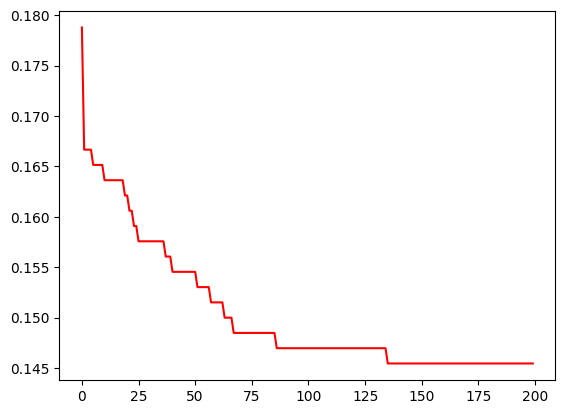

In [30]:
import matplotlib.pyplot as plt

fig=plt.figure()
ax=fig.add_subplot()
fig.show()

ax.plot(mm, color='r')
fig.canvas.draw()

In [31]:
Average_accuracy_with_FS=sum(average_accuracy)/len(average_accuracy)
Average_accuracy_with_FS

85.45454545454545

In [32]:
Average_accuracy_without_FS=Fnew1
Average_accuracy_without_FS

77.27272727272727

In [33]:
Average_no_of_features_selected=sum(average_feature)/len(average_feature)
Average_no_of_features_selected

4.6

In [34]:
Average_fitness=mm
Average_fitness

array([0.17878788, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16515152, 0.16515152, 0.16515152, 0.16515152, 0.16515152,
       0.16363636, 0.16363636, 0.16363636, 0.16363636, 0.16363636,
       0.16363636, 0.16363636, 0.16363636, 0.16363636, 0.16212121,
       0.16212121, 0.16060606, 0.16060606, 0.15909091, 0.15909091,
       0.15757576, 0.15757576, 0.15757576, 0.15757576, 0.15757576,
       0.15757576, 0.15757576, 0.15757576, 0.15757576, 0.15757576,
       0.15757576, 0.15757576, 0.15606061, 0.15606061, 0.15606061,
       0.15454545, 0.15454545, 0.15454545, 0.15454545, 0.15454545,
       0.15454545, 0.15454545, 0.15454545, 0.15454545, 0.15454545,
       0.15454545, 0.1530303 , 0.1530303 , 0.1530303 , 0.1530303 ,
       0.1530303 , 0.1530303 , 0.15151515, 0.15151515, 0.15151515,
       0.15151515, 0.15151515, 0.15151515, 0.15      , 0.15      ,
       0.15      , 0.15      , 0.14848485, 0.14848485, 0.14848485,
       0.14848485, 0.14848485, 0.14848485, 0.14848485, 0.14848